# Phase 4 - Evaluation & Visualization

In [ ]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import sys

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from evaluate import *
from model import *

# from train import *

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load Model & Data

### Via np export (Comment out if not used)

In [18]:
# Load Test Data
# Define paths for data and models

data_dir = Path("../data/processed")

X_train_path = data_dir / "X_train.npy"
X_test_path = data_dir / "X_test.npy"
y_train_path = data_dir / "y_train.npy"
y_test_path = data_dir / "y_test.npy"

# Load the data
X_train = np.load(X_train_path)
X_test = np.load(X_test_path)
y_train = np.load(y_train_path)
y_test = np.load(y_test_path)

class Autoencoder(tf.keras.Model):

    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(latent_dim, activation="relu")
        ])

        self.decoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(input_dim, activation="linear")
        ])

    def call(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model  = Autoencoder (input_dim = X_train.shape[1], latent_dim = 16)

# Compile the model
model.compile(optimizer = 'adam', loss = 'mse')

model.fit(X_train,X_train,epochs=50,batch_size=256)

# Load the model (assuming the model is saved in the 'models' directory)
model_path = Path("../models/autoencoder_model.keras")

if model_path.exists():
    model = keras.models.load_model(model_path)
    print("Model loaded successfully.")
else:
    print("Model file not found. Please ensure the model is trained and saved in the 'models' directory.")

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2087
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1191
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0905
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0707
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0577
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0497
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0448
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0391
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0358
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0323
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0291
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0259
Epoch 13/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0236
Epoch 14/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0221
Epoch 15/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

## Model Inference & Metric Calculationp (4.1)

Generating anomaly metrics and threshold
Train set Anomaly Threshold (Percentile 95): 0.0306



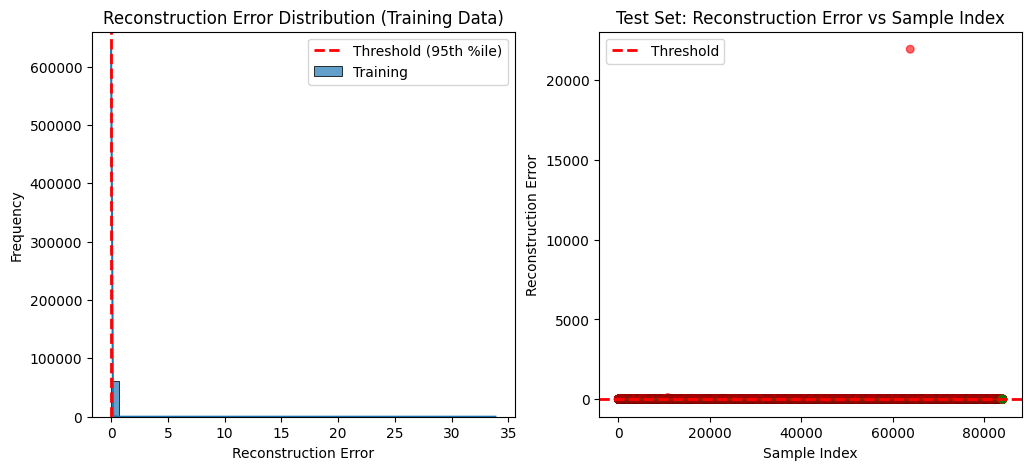

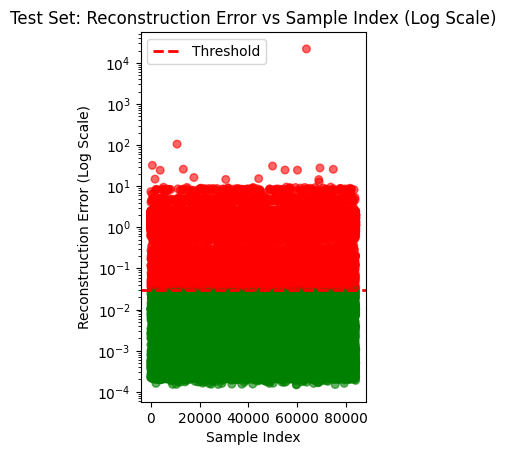

TEST SET EVALUATION METRICS
Accuracy: 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     26350
           1       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.97     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[24996  1354]
 [  481 57273]]


In [21]:
# Develop functions here (Finsihed function go into the .py files in the src folder)
...
### Same as baseline evaluation 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Global Variables for model development
THRESHOLD_PERCENTILE = 95

def calculate_reconstruction_error(model, data):
    """Calculate reconstruction error (MSE) for each sample."""
    reconstructed_data = model.predict(data, verbose=0)
    return np.mean(np.square(data - reconstructed_data), axis=1)

def generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE):
    """
    Generate anomaly threshold and evaluation metrics with visualization.
    
    Parameters:
    - model: Trained autoencoder model
    - X_train: Training data (for threshold calibration)
    - X_test: Test data (for evaluation)
    - y_test: Test labels
    - percentile: Percentile for threshold determination
    
    Returns:
    - threshold: Calculated anomaly threshold
    - y_pred: Predicted anomaly labels for test set
    """
    # Calculate reconstruction errors (single pass)
    train_errors = calculate_reconstruction_error(model, X_train)
    test_errors = calculate_reconstruction_error(model, X_test)
    
    # Determine threshold from training data
    threshold = np.percentile(train_errors, percentile)
    print(f"Train set Anomaly Threshold (Percentile {percentile}): {threshold:.4f}\n")
    
    # Predict anomalies for test set
    y_pred = np.where(test_errors > threshold, 1, 0)

    # Visualization 1: Reconstruction Error Distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_errors, bins=50, kde=True, label='Training', alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({percentile}th %ile)')
    plt.title('Reconstruction Error Distribution (Training Data)')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Visualization 2: Test Set Anomaly Detection
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.title('Test Set: Reconstruction Error vs Sample Index')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.legend()
    
    # plt.tight_layout()
    plt.show()
    
    # Visualization 2: Test Set Anomaly Detection (with Log Scale)
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.yscale('log') # <--- Added to handle extreme error scales cleanly
    plt.title('Test Set: Reconstruction Error vs Sample Index (Log Scale)')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error (Log Scale)')
    plt.legend()
    
    plt.show()

    # Evaluation Metrics
    print("="*50)
    print("TEST SET EVALUATION METRICS")
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


    return threshold, y_pred

print("Generating anomaly metrics and threshold")
threshold, y_pred = generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE)


## Model Inference & Metric Calculationp (4.1) & Visual Analytics Generation (4.2)

Generating anomaly metrics and threshold
Train set Anomaly Threshold (Percentile 95): 0.0306

Threshold: 0.03064102

Normal traffic:
Count:   26350
Min:     0.00014663
Median:  0.00151633
Mean:    0.01636526
Max:     106.07167053

Attack traffic:
Count:   57754
Min:     0.00653303
Median:  1.36283612
Mean:    1.85354853
Max:     21948.33398438

Percentiles:
 50.0%: 1.15552282
 75.0%: 1.70586622
 90.0%: 2.11712193
 95.0%: 2.30753160
 99.0%: 2.55416274
 99.9%: 8.35831928
100.0%: 21948.33398438
TEST SET EVALUATION METRICS
Accuracy:  0.9782
Precision: 0.9769
Recall:    0.9917
F1-Score:  0.9842

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96     26350
      Attack       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.97     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[24996  1354]
 [  481 57273]]


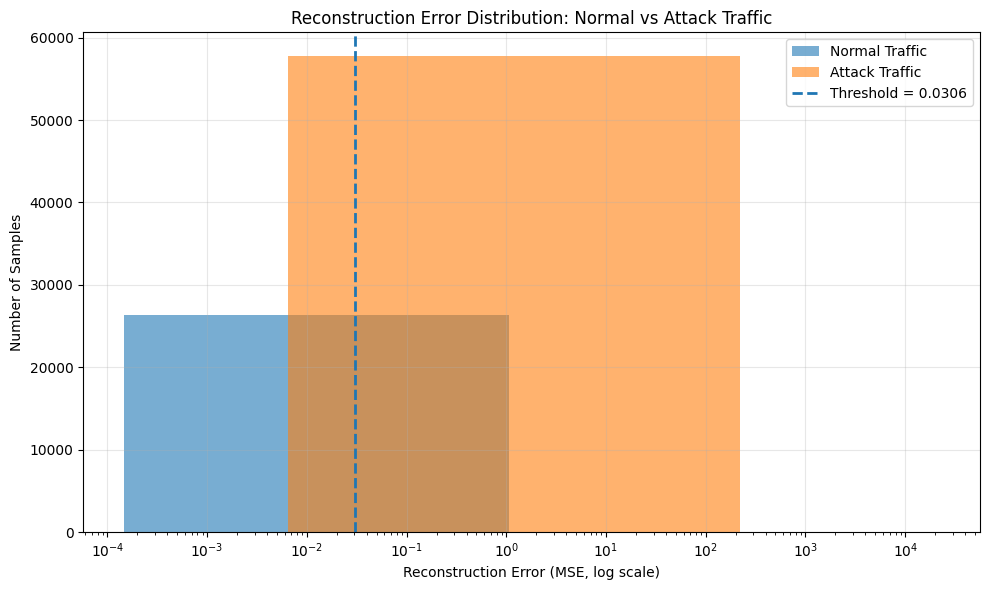

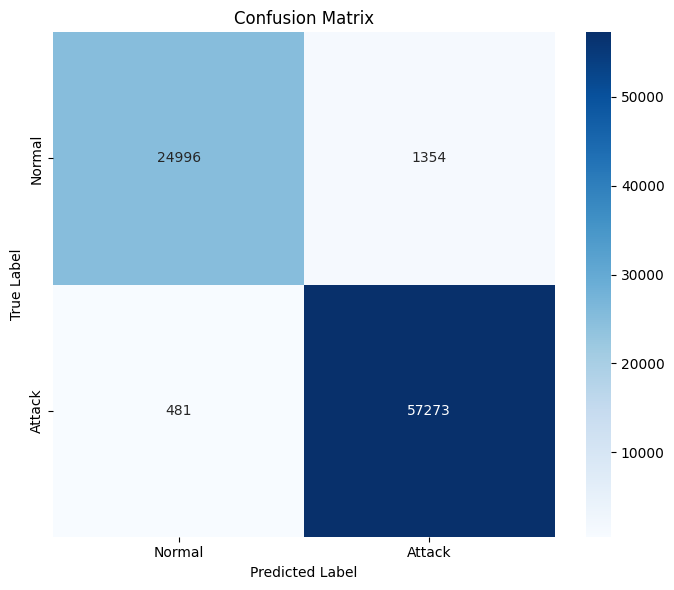

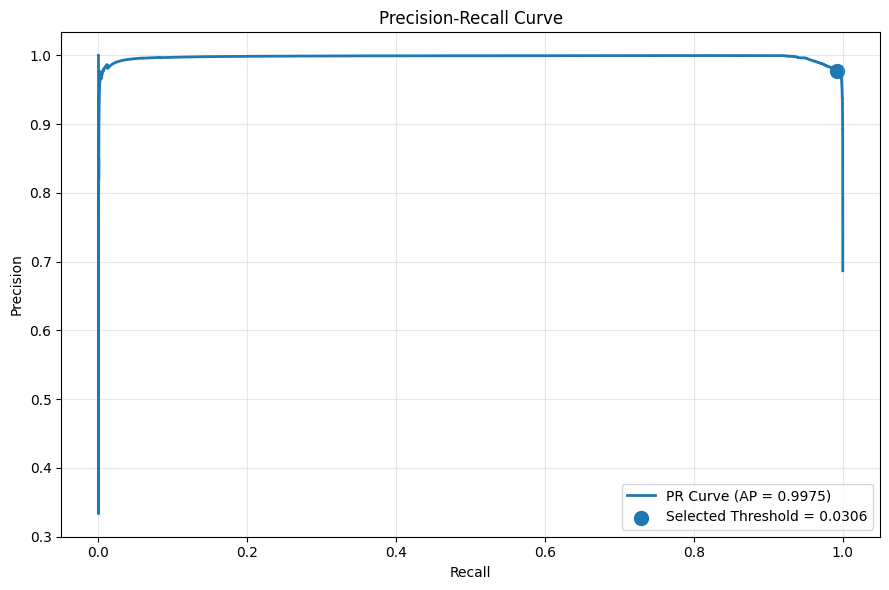

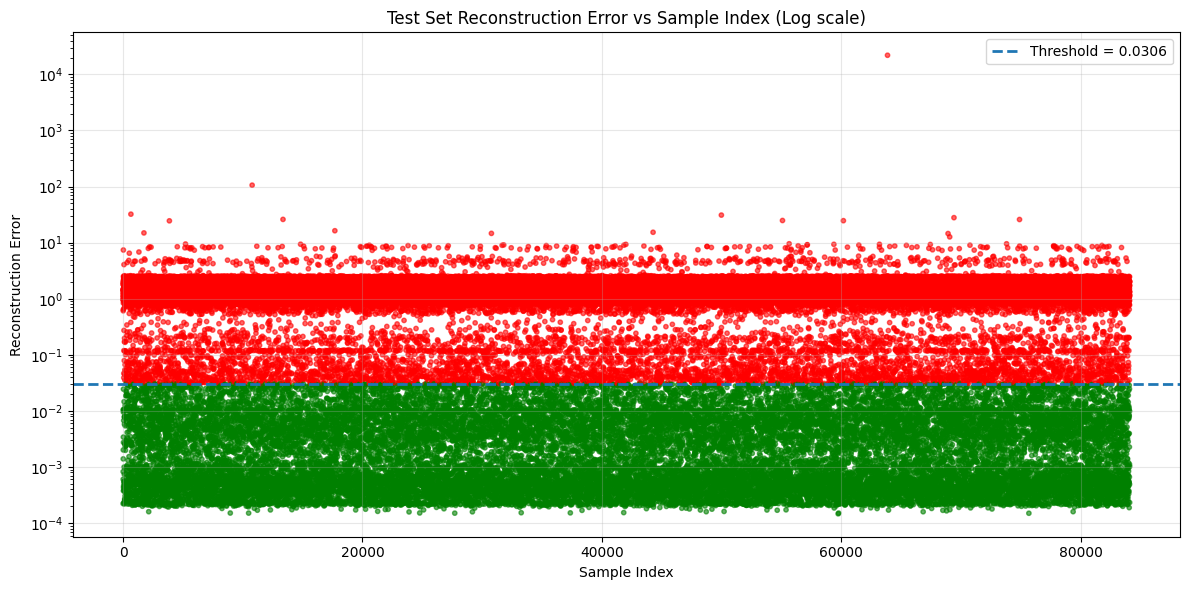

In [25]:
# Added visuals
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

from pathlib import Path

THRESHOLD_PERCENTILE = 95


def calculate_reconstruction_error(model, data):
    """Calculate reconstruction error (MSE) for each sample."""
    reconstructed_data = model.predict(data, verbose=0)
    return np.mean(np.square(data - reconstructed_data),axis=1)


def generate_anomaly_metrics_and_threshold(
    model,
    X_train,
    X_test,
    y_test,
    percentile=THRESHOLD_PERCENTILE
):
    """
    Generate anomaly threshold, evaluation metrics,
    visualizations, and save results.

    Returns:
        threshold: anomaly threshold
        y_pred: predicted labels
    """

    #Calculate Reconstruction Errors
    train_errors = calculate_reconstruction_error(model,X_train)
    test_errors = calculate_reconstruction_error(model,X_test)

    # Determine Threshold
    threshold = np.percentile(train_errors,percentile)

    print(
        f"Train set Anomaly Threshold "
        f"(Percentile {percentile}): {threshold:.4f}\n"
    )

    print(f"Threshold: {threshold:.8f}")
    print("\nNormal traffic:")
    normal_errors = test_errors[y_test == 0]
    print(f"Count:   {len(normal_errors)}")
    print(f"Min:     {normal_errors.min():.8f}")
    print(f"Median:  {np.median(normal_errors):.8f}")
    print(f"Mean:    {normal_errors.mean():.8f}")
    print(f"Max:     {normal_errors.max():.8f}")
    print("\nAttack traffic:")
    attack_errors = test_errors[y_test == 1]
    print(f"Count:   {len(attack_errors)}")
    print(f"Min:     {attack_errors.min():.8f}")
    print(f"Median:  {np.median(attack_errors):.8f}")
    print(f"Mean:    {attack_errors.mean():.8f}")
    print(f"Max:     {attack_errors.max():.8f}")
    print("\nPercentiles:")
    for p in [50, 75, 90, 95, 99, 99.9, 100]:
        print(
            f"{p:5.1f}%: "
            f"{np.percentile(test_errors, p):.8f}"
        )


    #Predict Normal / Anomaly
    # 0 = Normal
    # 1 = Attack / Anomaly

    y_pred = np.where(test_errors > threshold,1,0)

    # Create Results Directory
    results_dir = Path("../results")
    results_dir.mkdir(parents=True,exist_ok=True)

    #Calculate Metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred,zero_division=0)
    recall = recall_score(y_test,y_pred,zero_division=0)
    f1 = f1_score(y_test,y_pred,zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    #Print Evaluation Metrics
    print("TEST SET EVALUATION METRICS")

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

    print("Classification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Attack"],
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(cm)

    # Histogram: Normal vs Attack Reconstruction Errors

    plt.figure(figsize=(10, 6))

    plt.hist(
        test_errors[y_test == 0],
        bins=100,
        alpha=0.6,
        label="Normal Traffic"
    )

    plt.hist(
        test_errors[y_test == 1],
        bins=100,
        alpha=0.6,
        label="Attack Traffic"
    )

    plt.axvline(threshold,linestyle="--",linewidth=2,label=f"Threshold = {threshold:.4f}")
    plt.xscale("log")
    plt.xlabel("Reconstruction Error (MSE, log scale)")
    plt.ylabel("Number of Samples")
    plt.title("Reconstruction Error Distribution: Normal vs Attack Traffic")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        results_dir / "reconstruction_error_histogram.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    # Confusion Matrix
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    confusion_matrix_path = (results_dir /"confusion_matrix.png")
    plt.savefig(
        confusion_matrix_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    #Precision-Recall Curve

    precision_values, recall_values, pr_thresholds = (precision_recall_curve(y_test,test_errors))
    average_precision = average_precision_score(y_test,test_errors)
    plt.figure(figsize=(9, 6))
    plt.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=f"PR Curve (AP = {average_precision:.4f})"
    )

    # Mark the selected threshold
    if len(pr_thresholds) > 0:
        threshold_index = np.argmin(np.abs(pr_thresholds - threshold))
        selected_precision = (precision_values[threshold_index])
        selected_recall = (recall_values[threshold_index])
        plt.scatter(
            selected_recall,
            selected_precision,
            s=100,
            marker="o",
            label=(f"Selected Threshold = {threshold:.4f}")
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    pr_path = (results_dir /"precision_recall_curve.png")
    plt.savefig(
        pr_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    #Reconstruction Error vs Sample Index
    plt.figure(figsize=(12, 6))
    colors = [
        "green" if pred == 0 else "red"
        for pred in y_pred
    ]
    plt.scatter(
        range(len(test_errors)),
        test_errors,
        c=colors,
        alpha=0.6,
        s=10
    )
    plt.axhline(threshold,linestyle="--",linewidth=2,label=f"Threshold = {threshold:.4f}")
    plt.yscale("log")
    plt.xlabel("Sample Index")
    plt.ylabel("Reconstruction Error")
    plt.title("Test Set Reconstruction Error vs Sample Index (Log scale)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    sample_plot_path = (results_dir /"test_reconstruction_errors.png")
    plt.savefig(
        sample_plot_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    #Save Metrics
    metrics_path = (results_dir /"evaluation_metrics.txt")
    with open(metrics_path, "w") as f:
        f.write("Autoencoder Anomaly Detection Evaluation\n")
        f.write("----------------\n")
        f.write(f"Threshold Percentile: {percentile}\n")
        f.write(f"Anomaly Threshold: {threshold:.8f}\n\n")
        f.write(f"Accuracy:  {accuracy:.6f}\n")
        f.write(f"Precision: {precision:.6f}\n")
        f.write(f"Recall:    {recall:.6f}\n")
        f.write(f"F1-Score:  {f1:.6f}\n")
        f.write(f"Average Precision: "
            f"{average_precision:.6f}\n\n")
        f.write("Confusion Matrix\n")
        f.write("----------------\n")
        f.write(f"TN: {cm[0, 0]}\n")
        f.write(f"FP: {cm[0, 1]}\n")
        f.write(f"FN: {cm[1, 0]}\n")
        f.write(f"TP: {cm[1, 1]}\n")

    return threshold, y_pred
...
print("Generating anomaly metrics and threshold")
threshold, y_pred = generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE)



##  Visual Analytics Generation (4.2)

In [ ]:
# Develop functions here (Finsihed function go into the .py files in the src folder)
...

### implementeed in Generate anomaly metrics and threshold function in the above cell 

Ellipsis

In [6]:
# Test code cells here
...


Ellipsis